# Newton-Raphson Method

Probably the most famous iterative schema for finding roots, the equation to solve is:
$$
f(x) = 0
$$
And using linear Taylor approximation: 
$$
f(x + \Delta x) \approx f(x) +  f'(x) \cdot \Delta x
$$
One obtains the iterative schema:
$$
x_{n+1} = x_n - \dfrac{f(x_n)}{f'(x_n)}
$$
Where $x_0$ must be guessed. Also, if the derivative is too close to zero, the method may diverge.

In [1]:
import numpy as np

from utils.typing import (
    Real2Real,
    NumericType,
    ConvergenceError,
)

def newton_raphson(
        f: Real2Real,
        fprime: Real2Real,
        guess: NumericType,
        /,
        *,
        iterations: int = 5,
        tol: float = 1e-6,
        all: bool = False,
) -> NumericType:
    x = np.empty((iterations, ), np.float64)
    x[0] = guess
    i = 0
    err = 1.
    while i < iterations - 1 and  err > tol:
        x[i + 1] = x[i] - f(x[i]) / fprime(x[i])
        err = np.abs(f(x[i + 1]))
        i += 1

    if i < iterations or np.abs(err) <= tol:
        return x[: i + 1] if all else x[i]
    raise ConvergenceError(
        f"Solution could not converge to 0 with an error tolerance smaller"
        f"than '{tol}' after {iterations} iterations."
    )


### Example
Consider the equation $x \exp(x) = 1$. Then our $f$ would have the form $f(x) = x \exp(x) - 1$.

In [2]:
def func(x: float) -> float:
    return x * np.exp(x) - 1

def fprime(x: float) -> float:
    return (x + 1) * np.exp(x)

funclabel = r"$x \exp(x) - 1$"

We can plot the nature of $f(x) = x \exp(x)$ to give ourselves an idea of what our guessing point should be.

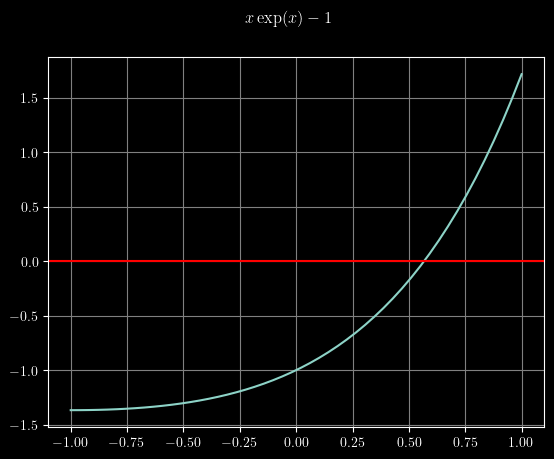

In [3]:
import matplotlib.pyplot as plt
from utils.visualization import map_plot, init

init()

fig, ax = plt.subplots()
ax = map_plot(func, [-1, 1], ax)

fig.suptitle(funclabel)
ax.axhline(y=0, color='red')
ax.grid(True, color='gray')

plt.show()

We can tell that the intersection point must lie within the range [0.50, 0.75]. Hence, our first guess could be the midpoint.

In [4]:
guess = (.75 + .5) / 2
res = newton_raphson(func, fprime, guess, all=True)

Plotting the result, it converges pretty fast: after three iterations the points are barely distinguishable between them

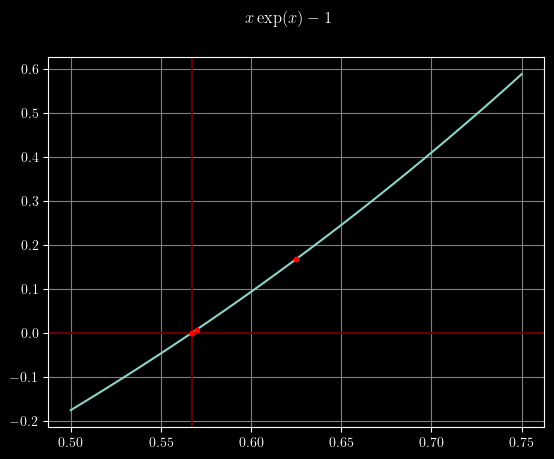

In [5]:
from utils.colors import darker
darker_red = darker('red', 0.6)

fig, ax = plt.subplots()
ax = map_plot(func, [.5, .75], ax)

# some styling
fig.suptitle(r"$x \exp(x) - 1$")
ax.axhline(0, color=darker_red)
ax.axvline(res[-1], color=darker_red)
ax.scatter(res, func(res), color='red', zorder=3, s=10)
ax.grid(True, color='gray')

plt.show()

### Multidimensional Newton Raphson Method
Technically speaking, the system can be generalized to $\mathbb{R}^n$. Let $f: \mathbb{R}^n \rightarrow \mathbb{R}^n$ and consider:
$$
f(x) = 
\begin{pmatrix} 
f_1(x) \\
f_2(x) \\
\vdots \\
f_n(x) \\
\end{pmatrix}
= 0
$$
Where the linear Taylor approximation is no longer a single derivative but the Jacobian:
$$
f(x + \Delta x) \approx f(x) + {\bf J}(x) \Delta x
$$
Hence, the iterative schema is now:
$$x_{n+1} = x_n - (J_n)^{-1} \cdot f(x_n)$$
However, it is quite expensive to compute the inverse of the Jacobian $J_n$ at each $x_n$. Hence we can use what is known as the Broyden's method.

## Broyden's Method
The method consists on estimating ${\rm inv} J_{n+1}$ from ${\rm inv} J_n$ instead of taking the inverse at each step: a huge improvement. The estimation is:
$$
{\rm inv} J_{n+1} = {\rm inv} J_n - \dfrac{({\rm inv} J_n \cdot \delta^f_n - \delta^x_n) (\delta^x_n)^T \cdot {\rm inv} J_n }{(\delta^x_n)^T \cdot {\rm inv} J_n \cdot \delta^f_n}
$$
Where $\delta^x_n := x_{n+1} - x_n$, and $\delta^f_n := f(x_{n+1}) - f(x_n)$

In [28]:
from utils.typing import NumpyVector, NumpyMatrix

def next_invjacobian(
        invjn: NumpyMatrix,
        deltaxn: NumpyVector,
        deltafn: NumpyVector,
) -> NumpyMatrix:
    deltasop = invjn @ deltafn - deltaxn
    numerator = np.outer(deltasop, deltaxn) @ invjn
    denominator = deltaxn @ invjn @ deltafn
    return invjn - numerator/denominator

### Example
Let's consider for example the following equation:
$$
\begin{align*}
y \sin(x) + x \sin(y) &= 0 \\
\exp(- \exp(- x - y)) - y (x^2 + 1) &= 0
\end{align*}
$$

With Jacobian: 
$$
\begin{pmatrix}
y \cos(x) + \cos(y) & \sin(x) - x \sin(y) \\
{\rm e}^{(-(x + y) \exp (- x - y))} - 2 x y & {\rm e}^{(-(x + y) \exp (- x - y))} - 1 \\
\end{pmatrix}
$$

In [20]:
from utils.typing import NumpyVector, NumpyMatrix

def expexp(x: float, y: float, /,) -> float:
    return np.exp(-(x + y) * np.exp(- (x + y)))


def multifunc(x: float, y: float, /,) -> NumpyVector:
    first = y * np.sin(x) + x * np.sin(y)
    second = np.exp(- np.exp(-x - y)) - y * (x**2 + 1)
    return np.array([first, second], np.float64)


def jacobian(x: float, y: float, /,) -> NumpyMatrix:
    j11 = y * np.cos(x) + np.cos(y)
    j12 = np.sin(x) - x * np.sin(y)
    j21 = expexp(x, y) - 2 * x* y
    j22 = expexp(x, y) - 1
    return np.array([[j11, j12], [j21, j22]], np.float64)

Implementing the iterative method

In [ ]:
from utils.typing import Vector2Vector, Vector2Matrix

def broyden(
        multif: Vector2Vector,
        jacob: Vector2Matrix,
        guess: NumpyVector,
        /,
        *, 
        iterations: int = 10,
        tol: float = 1e-10,
        all: bool = True 
):
    n, = guess.shape
    sols = np.empty((iterations, n), np.float64)
    sols[0] = guess
    invjn = np.linalg.inv(jacob(sols[0]))
    deltafn = multif(sols[0])
    sols[1] = sols[0] - invjn @ deltafn
    err = np.linalg.norm(deltafn)
    i = 0
    while err > tol:
        i += 1
        deltaxn = sols[i] - sols[i-1]
        fn = multif(sols[i])
        deltafn = fn - multif(sols[i-1]) 
        invjn = next_invjacobian(invjn, deltaxn, deltafn)
        sols[i+1] = sols[i] - invjn @ fn
        err = np.linalg.norm(sols[i+1] - sols[i])

        # check iterations
        if i > iterations:
            raise ConvergenceError(
                f"No solution found after {iterations} iterations with a" 
                f"tolerance of {tol:.5e}."
            )

    return sols[: i] if all else sols[i+1]

Coding some wrappers (so `np.array` works smoothly on it) and setting initial guess. Then call the `broyden` method.

In [ ]:
def wrap_multifunc(arr: NumpyVector) -> NumpyVector:
    return multifunc(*arr)

def wrap_jacobian(arr: NumpyVector) -> NumpyMatrix:
    return jacobian(*arr)

guess = np.array([0.3, 0.6])
res = broyden(wrap_multifunc, wrap_jacobian, guess)

In [ ]:
labels = [
    r"$y \sin(x) + x \sin(y)$",
    r"$\exp(- \exp(- x - y)) - y (x^2 + 1)$"
]

In [ ]:
from utils.visualization import plot_3d
from utils.visualization import gen_scattered_path_3d


fig = plot_3d(multifunc, [0, 1, 100], [0, 1, 100], 
              uniformcolors=['red', 'blue'],
              dark=True)

scatters = gen_scattered_path_3d(multifunc, res, 
                                 colors=['red', 'blue'],
                                 labels=labels,)
fig.add_traces(scatters)
fig.update_layout(title={'text': "Broyden method approximation"},
                  scene=dict(xaxis={'range': [-0.4, 0.4]},
                             yaxis={'range': [0.2, 0.8]},
                             zaxis={'range': [-0.5, 0.5]},))

fig.show()

# Useful links
* https://pages.hmc.edu/ruye/MachineLearning/lectures/ch2/node7.html
* https://en.wikipedia.org/wiki/Newton%27s_method
* https://en.wikipedia.org/wiki/Broyden%27s_method